
# Information Is Physical: Synthetic Benchmarking Notebook

This notebook simulates three benchmark-inspired datasets for comparative analysis of **physically embodied information**:

1. DNA information maintenance  
2. Brain memory energetics  
3. Computer-bit thermodynamics  

The datasets are **synthetic**, but their parameter ranges are anchored to peer-reviewed PubMed-indexed literature.

Key anchors used for simulation:
- endogenous DNA damage on the order of **10<sup>4</sup> to 10<sup>5</sup> lesions per cell per day** in mammalian cells, with active repair required for fidelity, from Lindahl and follow-up reviews (Lindahl, 1993; Barnes & Lindahl, 2004; Timmins et al., 2023).
- adult brain glucose utilization near **~0.3 μmol/g/min** at rest, increasing with activation, with strong coupling of energetics to neural function (Dienel, 2019; Mangia et al., 2009; Mergenthaler et al., 2013).
- healthy human brain glycogen near **7.8 ± 0.3 μmol/g** (Öz et al., 2015).
- long-term synaptic plasticity and memory consolidation requiring new protein synthesis and structural remodeling (Steward & Worley, 2001; Steward & Worley, 2002; Costa-Mattioli et al., 2009; Rosenberg & Gal-Ben-Ari, 2014; Bailey et al., 2015; Roesler et al., 2017).
- irreversible bit erasure bounded by **k_B T ln 2** from Landauer’s principle (Chattopadhyay et al., 2025).

The notebook includes:
- simulation,
- exploratory analysis,
- machine learning and AI-style modeling,
- cross-system integration,
- visualization in notebook cells.

## References used to benchmark simulation ranges

1.	Bailey, C. H., Kandel, E. R., & Harris, K. M. (2015). Structural components of synaptic plasticity and memory consolidation. Cold Spring Harbor Perspectives in Biology, 7(7), a021758.
https://doi.org/10.1101/cshperspect.a021758  
2.	Barnes, D. E., & Lindahl, T. (2004). Repair and genetic consequences of endogenous DNA base damage in mammalian cells. Annual Review of Genetics, 38, 445–476.
https://www.annualreviews.org/content/journals/10.1146/annurev.genet.38.072902.092448 
3.	Chattopadhyay, P., Misra, A., Pandit, T., & Paul, G. (2025). Landauer principle and thermodynamics of computation. Reports on Progress in Physics, 88(8), 086601.
https://iopscience.iop.org/article/10.1088/1361-6633/add6b3 
4.	Costa-Mattioli, M., Sossin, W. S., Klann, E., & Sonenberg, N. (2009). Translational control of long-lasting synaptic plasticity and memory. Neuron, 61(1), 10–26.
https://doi.org/10.1016/j.neuron.2008.10.055   
5.	Dienel, G. A. (2019). Brain glucose metabolism: Integration of energetics with function. Physiological Reviews, 99(1), 949–1045.
https://journals.physiology.org/doi/full/10.1152/physrev.00062.2017
6.	Eustermann, S., Patel, A.B., Hopfner, KP. et al. (2024). Energy-driven genome regulation by ATP-dependent chromatin remodellers. Nat Rev Mol Cell Biol 25, 309–332. https://doi.org/10.1038/s41580-023-00683-y
7.	Lindahl, T. (1993). Instability and decay of the primary structure of DNA. Nature, 362(6422), 709–715. https://www.nature.com/articles/362709a0 
8.	Mangia, S., Simpson, I.A., Vannucci, S.J. and Carruthers, A. (2009), The in vivo neuron-to-astrocyte lactate shuttle in human brain: evidence from modeling of measured lactate levels during visual stimulation. Journal of Neurochemistry, 109: 55-62. https://doi.org/10.1111/j.1471-4159.2009.06003.x 
9.	Mergenthaler, P., Lindauer, U., Dienel, G. A., & Meisel, A. (2013). Sugar for the brain: The role of glucose in physiological and pathological brain function. Trends in Neurosciences, 36(10), 587–597. https://doi.org/10.1016/j.tins.2013.07.001 
10.	Öz, G., et al. (2015). Revisiting glycogen content in the human brain. Neurochemical Research, 40(12), 2473–2481.
https://doi.org/10.1007/s11064-015-1664-4  
11.	Roesler, R.(2017). Molecular mechanisms controlling protein synthesis in memory reconsolidation. Neurobiology of Learning and Memory, 142(Pt A), 30–40. https://doi.org/10.1016/j.nlm.2017.04.015 
12.	Rosenberg, T., & Gal-Ben-Ari, S. (2014). The roles of protein expression in synaptic plasticity and memory consolidation. Frontiers in Molecular Neuroscience, 7, 86. https://doi.org/10.3389/fnmol.2014.00086 
13.	Steward, O., & Worley, P. F. (2001). A cellular mechanism for targeting newly synthesized mRNAs to synaptic sites on dendrites. PNAS, 98(13), 7062–7068. https://doi.org/10.1073/pnas.131146398 
14.	Steward, O., & Worley, P. F. (2002). Local synthesis of proteins at synaptic sites on dendrites: Role in synaptic plasticity and memory consolidation? Neurobiology of Learning and Memory, 78(3), 508–527. https://doi.org/10.1006/nlme.2002.4102 
15.	Timmins, J. (2023). Recognition of DNA lesions. International Journal of Molecular Sciences, 24(11), 9682. https://doi.org/10.3390/ijms24119682

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, roc_auc_score, accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.inspection import permutation_importance

np.random.seed(42)
k_B = 1.380649e-23

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


## 1. Simulate benchmark-inspired datasets

In [5]:

# DNA dataset
n_dna = 1400
dna = pd.DataFrame({
    "lesions_per_day": np.random.uniform(1e4, 1e5, n_dna),
    "oxidative_fraction": np.random.uniform(0.1, 0.6, n_dna),
    "repair_efficiency": np.random.uniform(0.94, 0.9995, n_dna),
    "chromatin_remodeling_index": np.random.uniform(0.5, 2.0, n_dna),
    "replication_stress_index": np.random.uniform(0.0, 1.0, n_dna),
    "antioxidant_capacity_index": np.random.uniform(0.2, 1.5, n_dna),
    "cell_cycle_pressure_index": np.random.uniform(0.0, 1.0, n_dna)
})
residual_damage = dna["lesions_per_day"] * (1 - dna["repair_efficiency"])
oxidative_burden = dna["lesions_per_day"] * dna["oxidative_fraction"] / 1e4
dna_signal = (
    5.2
    - 0.00005 * residual_damage
    - 0.35 * oxidative_burden
    - 1.1 * dna["replication_stress_index"]
    - 0.8 * dna["cell_cycle_pressure_index"]
    + 1.0 * dna["chromatin_remodeling_index"]
    + 0.9 * dna["antioxidant_capacity_index"]
)
dna["dna_information_fidelity"] = np.clip(100 * sigmoid(dna_signal - 3.2) + np.random.normal(0, 3.0, n_dna), 0, 100)
dna["high_integrity_state"] = (dna["dna_information_fidelity"] >= 70).astype(int)

# Brain dataset
n_brain = 1400
brain = pd.DataFrame({
    "cmr_glucose_umol_g_min": np.random.uniform(0.25, 0.45, n_brain),
    "activity_increase_pct": np.random.uniform(0, 35, n_brain),
    "glycogen_umol_g": np.random.normal(7.8, 0.5, n_brain).clip(6.0, 10.0),
    "protein_synthesis_index": np.random.uniform(0.3, 2.2, n_brain),
    "synaptic_remodeling_index": np.random.uniform(0.2, 2.2, n_brain),
    "sleep_support_index": np.random.uniform(0.0, 1.0, n_brain),
    "oxidative_stress_index": np.random.uniform(0.0, 1.0, n_brain),
    "injury_burden_index": np.random.uniform(0.0, 1.0, n_brain)
})
brain_signal = (
    2.2
    + 5.5 * (brain["cmr_glucose_umol_g_min"] - 0.30)
    + 0.025 * brain["activity_increase_pct"]
    + 0.55 * (brain["glycogen_umol_g"] - 7.8)
    + 1.3 * brain["protein_synthesis_index"]
    + 1.15 * brain["synaptic_remodeling_index"]
    + 0.8 * brain["sleep_support_index"]
    - 1.2 * brain["oxidative_stress_index"]
    - 1.8 * brain["injury_burden_index"]
)
brain["memory_retention_score"] = np.clip(100 * sigmoid(brain_signal - 4.8) + np.random.normal(0, 4.0, n_brain), 0, 100)
brain["high_memory_state"] = (brain["memory_retention_score"] >= 70).astype(int)

# Bit dataset
n_bit = 1400
bit = pd.DataFrame({
    "temperature_K": np.random.uniform(250, 400, n_bit),
    "energy_barrier_multiple_of_landauer": np.random.uniform(5, 1500, n_bit),
    "leakage_index": np.random.uniform(0.0, 1.0, n_bit),
    "error_correction_strength": np.random.uniform(0.0, 1.0, n_bit),
    "switching_frequency_GHz": np.random.uniform(0.1, 6.0, n_bit),
    "radiation_noise_index": np.random.uniform(0.0, 1.0, n_bit)
})
bit["landauer_bound_J"] = k_B * bit["temperature_K"] * np.log(2)
bit["practical_reset_energy_J"] = bit["landauer_bound_J"] * bit["energy_barrier_multiple_of_landauer"]
bit_signal = (
    2.8
    + 0.004 * bit["energy_barrier_multiple_of_landauer"]
    + 1.6 * bit["error_correction_strength"]
    - 2.0 * bit["leakage_index"]
    - 1.3 * bit["radiation_noise_index"]
    - 0.35 * (bit["temperature_K"] - 300) / 25
    - 0.12 * bit["switching_frequency_GHz"]
)
bit["bit_reliability_score"] = np.clip(100 * sigmoid(bit_signal - 2.7) + np.random.normal(0, 3.0, n_bit), 0, 100)
bit["high_reliability_state"] = (bit["bit_reliability_score"] >= 70).astype(int)

print(dna.shape, brain.shape, bit.shape)
dna.head()


(1400, 9) (1400, 10) (1400, 10)


,lesions_per_day,oxidative_fraction,repair_efficiency,chromatin_remodeling_index,replication_stress_index,antioxidant_capacity_index,cell_cycle_pressure_index,dna_information_fidelity,high_integrity_state
0,43708.610696,0.183521,0.987159,1.774939,0.268143,0.250439,0.499036,93.351635,1
1,95564.287577,0.183810,0.994020,0.794369,0.315668,0.442804,0.931535,82.906582,1
2,75879.454763,0.118336,0.996150,0.688325,0.125251,1.280620,0.583333,95.979022,1
3,63879.263578,0.468201,0.997128,1.945220,0.655510,1.196799,0.538384,91.916332,1
4,24041.677640,0.431902,0.971027,0.662067,0.039797,0.655835,0.454483,96.289084,1


## 2. Descriptive statistics and benchmark checks

In [8]:

summary_table = pd.concat({
    "DNA": dna.describe().T,
    "Brain": brain.describe().T,
    "Bit": bit.describe().T
})
summary_table.round(4)


count        mean         std  \
DNA   lesions_per_day                      1400.0  54831.2638  26457.8163   
      oxidative_fraction                   1400.0      0.3491      0.1446   
      repair_efficiency                    1400.0      0.9695      0.0171   
      chromatin_remodeling_index           1400.0      1.2430      0.4301   
      replication_stress_index             1400.0      0.4956      0.2910   
      antioxidant_capacity_index           1400.0      0.8298      0.3696   
      cell_cycle_pressure_index            1400.0      0.4905      0.2806   
      dna_information_fidelity             1400.0     88.5933      9.1370   
      high_integrity_state                 1400.0      0.9514      0.2150   
Brain cmr_glucose_umol_g_min               1400.0      0.3492      0.0585   
      activity_increase_pct                1400.0     17.2211     10.3741   
      glycogen_umol_g                      1400.0      7.8050      0.4945   
      protein_synthesis_index              1400.0      1.2791      0.5392   
      synaptic_remodeling_index            1400.0      1.2292      0.5703   
      sleep_support_index                  1400.0      0.5024      0.2894   
      oxidative_stress_index               1400.0      0.5093      0.2934   
      injury_burden_index                  1400.0      0.5210      0.2882   
      memory_retention_score               1400.0     50.7254     25.2038   
      high_memory_state                    1400.0      0.2779      0.4481   
Bit   temperature_K                        1400.0    324.2394     42.7462   
      energy_barrier_multiple_of_landauer  1400.0    746.0603    433.0939   
      leakage_index                        1400.0      0.4829      0.2795   
      error_correction_strength            1400.0      0.4965      0.2892   
      switching_frequency_GHz              1400.0      3.0609      1.7277   
      radiation_noise_index                1400.0      0.4992      0.2854   
      landauer_bound_J                     1400.0      0.0000      0.0000   
      practical_reset_energy_J             1400.0      0.0000      0.0000   
      bit_reliability_score                1400.0     71.2763     28.1462   
      high_reliability_state               1400.0      0.6164      0.4864   

                                                  min         25%         50%  \
DNA   lesions_per_day                      10416.8821  31372.2789  55294.9088   
      oxidative_fraction                       0.1001      0.2280      0.3503   
      repair_efficiency                        0.9400      0.9548      0.9697   
      chromatin_remodeling_index               0.5003      0.8749      1.2260   
      replication_stress_index                 0.0014      0.2393      0.4896   
      antioxidant_capacity_index               0.2003      0.5127      0.8284   
      cell_cycle_pressure_index                0.0001      0.2549      0.4851   
      dna_information_fidelity                34.1322     84.1505     90.8416   
      high_integrity_state                     0.0000      1.0000      1.0000   
Brain cmr_glucose_umol_g_min                   0.2500      0.2979      0.3472   
      activity_increase_pct                    0.0467      7.9350     16.7933   
      glycogen_umol_g                          6.1394      7.4842      7.7993   
      protein_synthesis_index                  0.3005      0.8341      1.3022   
      synaptic_remodeling_index                0.2025      0.7540      1.2335   
      sleep_support_index                      0.0006      0.2523      0.5006   
      oxidative_stress_index                   0.0025      0.2573      0.5192   
      injury_burden_index                      0.0000      0.2806      0.5321   
      memory_retention_score                   0.0000     29.8460     50.9725   
      high_memory_state                        0.0000      0.0000      0.0000   
Bit   temperature_K                          250.0165    288.0649    324.1432   
      energy_barrier_multiple_of

In [10]:

benchmark_checks = pd.DataFrame({
    "System": ["DNA", "Brain", "Brain", "Bit"],
    "Variable": ["Lesions per day", "Resting glucose utilization", "Brain glycogen", "Landauer bound at 300 K"],
    "Notebook value": [
        dna["lesions_per_day"].mean(),
        brain["cmr_glucose_umol_g_min"].mean(),
        brain["glycogen_umol_g"].mean(),
        float(k_B * 300 * np.log(2))
    ],
    "Literature anchor": [
        "10^4 to 10^5 lesions/cell/day",
        "~0.3 μmol/g/min baseline, rising with activation",
        "~7.8 ± 0.3 μmol/g",
        "k_B T ln 2"
    ]
})
benchmark_checks


,System,Variable,Notebook value,Literature anchor
0,DNA,Lesions per day,5.483126e+04,10^4 to 10^5 lesions/cell/day
1,Brain,Resting glucose utilization,3.492151e-01,"~0.3 μmol/g/min baseline, rising with activation"
2,Brain,Brain glycogen,7.805017e+00,~7.8 ± 0.3 μmol/g
3,Bit,Landauer bound at 300 K,2.870979e-21,k_B T ln 2


## 3. Visualization

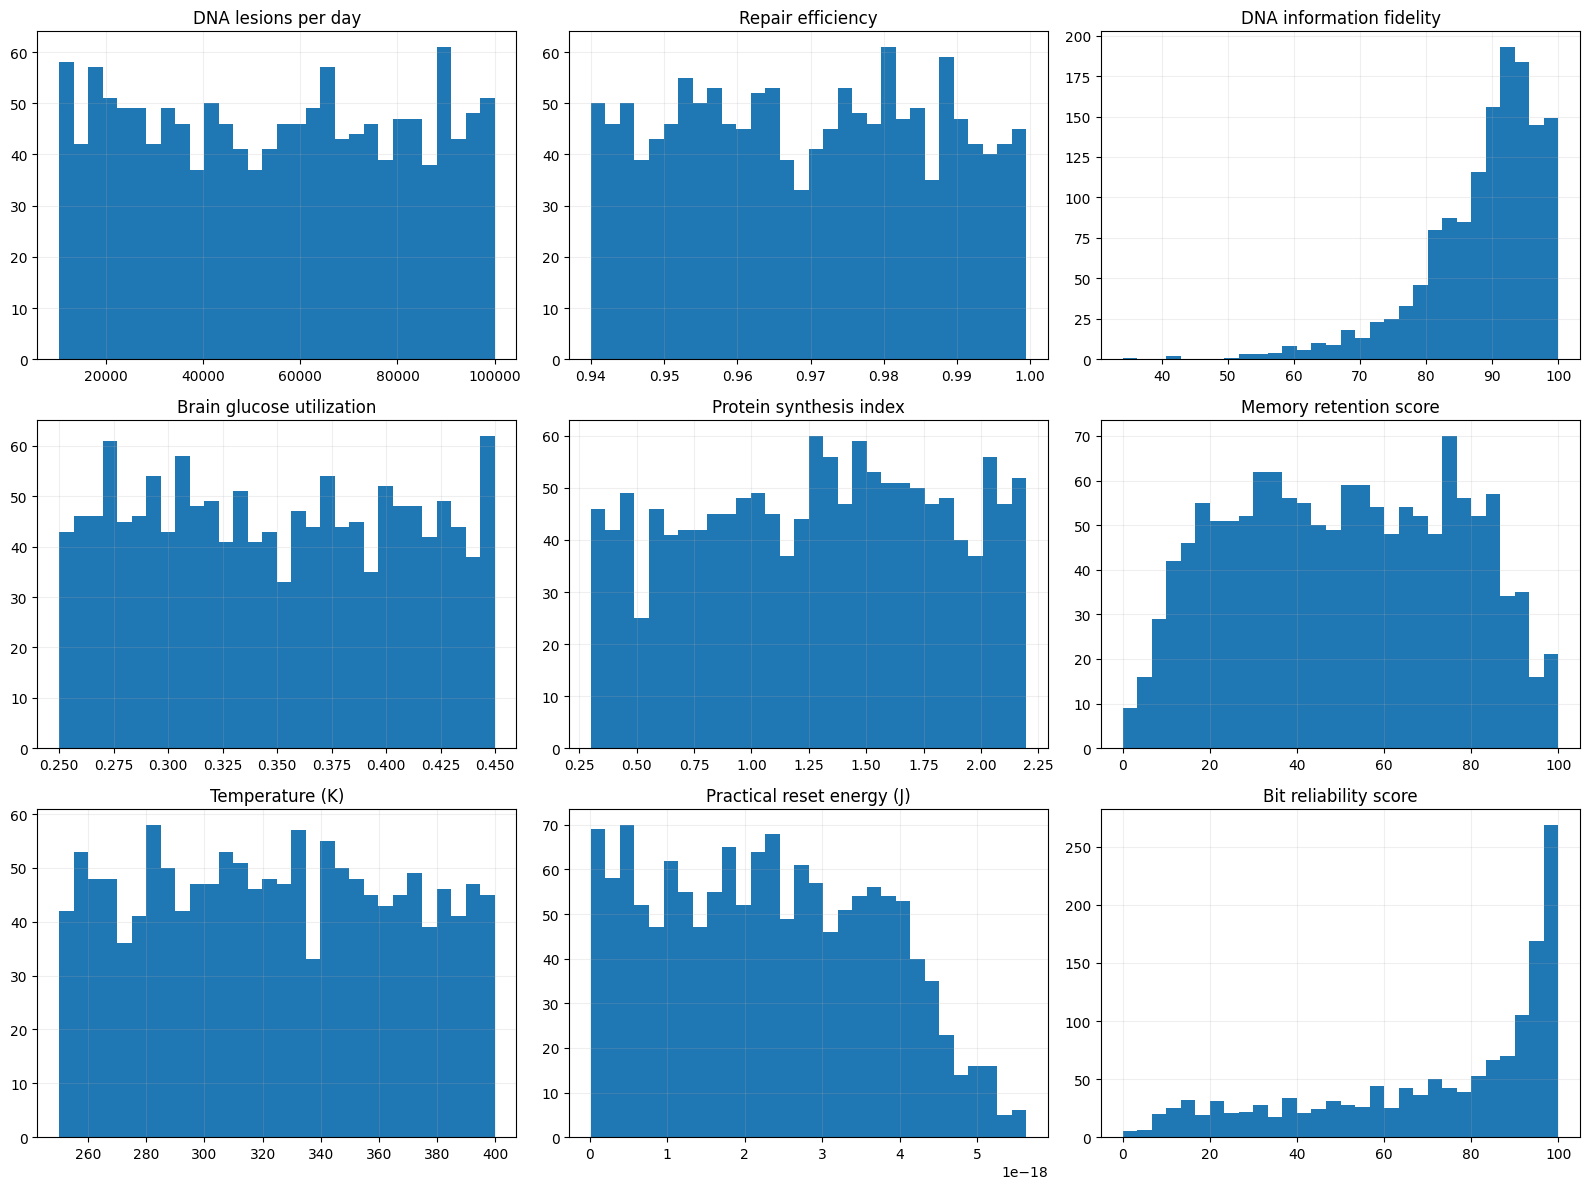

In [12]:

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

axes[0,0].hist(dna["lesions_per_day"], bins=30)
axes[0,0].set_title("DNA lesions per day")
axes[0,1].hist(dna["repair_efficiency"], bins=30)
axes[0,1].set_title("Repair efficiency")
axes[0,2].hist(dna["dna_information_fidelity"], bins=30)
axes[0,2].set_title("DNA information fidelity")

axes[1,0].hist(brain["cmr_glucose_umol_g_min"], bins=30)
axes[1,0].set_title("Brain glucose utilization")
axes[1,1].hist(brain["protein_synthesis_index"], bins=30)
axes[1,1].set_title("Protein synthesis index")
axes[1,2].hist(brain["memory_retention_score"], bins=30)
axes[1,2].set_title("Memory retention score")

axes[2,0].hist(bit["temperature_K"], bins=30)
axes[2,0].set_title("Temperature (K)")
axes[2,1].hist(bit["practical_reset_energy_J"], bins=30)
axes[2,1].set_title("Practical reset energy (J)")
axes[2,2].hist(bit["bit_reliability_score"], bins=30)
axes[2,2].set_title("Bit reliability score")

for ax in axes.ravel():
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


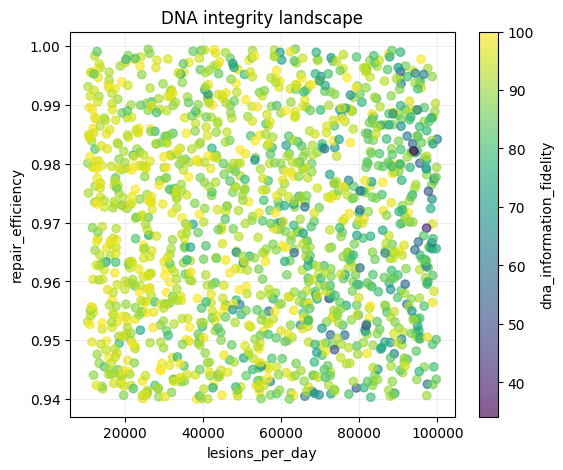

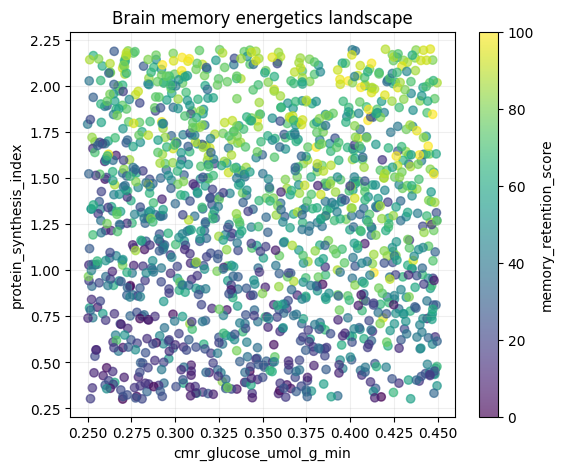

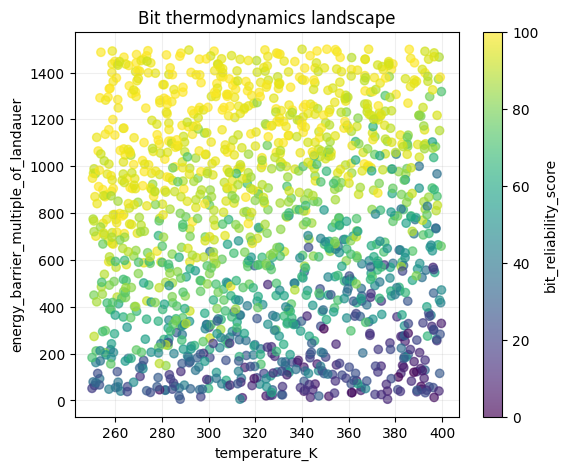

In [14]:

def scatter_with_color(df, x, y, c, title):
    plt.figure(figsize=(6.2, 5))
    sc = plt.scatter(df[x], df[y], c=df[c], alpha=0.65)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.colorbar(sc, label=c)
    plt.grid(alpha=0.2)
    plt.show()

scatter_with_color(dna, "lesions_per_day", "repair_efficiency", "dna_information_fidelity", "DNA integrity landscape")
scatter_with_color(brain, "cmr_glucose_umol_g_min", "protein_synthesis_index", "memory_retention_score", "Brain memory energetics landscape")
scatter_with_color(bit, "temperature_K", "energy_barrier_multiple_of_landauer", "bit_reliability_score", "Bit thermodynamics landscape")


## 4. Correlation analysis

In [17]:

for name, df, target in [
    ("DNA", dna, "dna_information_fidelity"),
    ("Brain", brain, "memory_retention_score"),
    ("Bit", bit, "bit_reliability_score"),
]:
    print(f"\n{name} correlations with {target}")
    print(df.corr(numeric_only=True)[target].sort_values(ascending=False).round(3))



DNA correlations with dna_information_fidelity
dna_information_fidelity      1.000
high_integrity_state          0.653
chromatin_remodeling_index    0.449
antioxidant_capacity_index    0.347
repair_efficiency             0.026
cell_cycle_pressure_index    -0.216
oxidative_fraction           -0.326
replication_stress_index     -0.354
lesions_per_day              -0.401
Name: dna_information_fidelity, dtype: float64

Brain correlations with memory_retention_score
memory_retention_score       1.000
high_memory_state            0.773
protein_synthesis_index      0.569
synaptic_remodeling_index    0.507
glycogen_umol_g              0.212
sleep_support_index          0.212
cmr_glucose_umol_g_min       0.203
activity_increase_pct        0.132
oxidative_stress_index      -0.229
injury_burden_index         -0.427
Name: memory_retention_score, dtype: float64

Bit correlations with bit_reliability_score
bit_reliability_score                  1.000
high_reliability_state                 0.873
ene

## 5. Machine learning regression

In [20]:

def evaluate_regression_models(df, target):
    X = df.drop(columns=[target] + [c for c in df.columns if c.startswith("high_")])
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    models = {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "RandomForest": RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1),
        "GradientBoosting": GradientBoostingRegressor(random_state=42),
        "MLPRegressor": MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
    }
    results = []
    fitted = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        results.append({
            "model": name,
            "R2": r2_score(y_test, pred),
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": rmse(y_test, pred)
        })
        fitted[name] = (model, X_test, y_test, pred)
    return pd.DataFrame(results).sort_values("R2", ascending=False), fitted

dna_results, dna_fitted = evaluate_regression_models(dna, "dna_information_fidelity")
brain_results, brain_fitted = evaluate_regression_models(brain, "memory_retention_score")
bit_results, bit_fitted = evaluate_regression_models(bit, "bit_reliability_score")

print("DNA")
display(dna_results)
print("Brain")
display(brain_results)
print("Bit")
display(bit_results)


/opt/anaconda3/envs/qiskit_legacy_env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


DNA


,model,R2,MAE,RMSE
3,GradientBoosting,0.820664,2.907553,3.706672
2,RandomForest,0.757248,3.274270,4.312529
0,LinearRegression,0.752588,3.231398,4.353725
1,Ridge,0.750753,3.225535,4.369839
4,MLPRegressor,-23.320655,36.521807,43.165668


Brain


,model,R2,MAE,RMSE
0,LinearRegression,0.960085,3.976590,4.997985
1,Ridge,0.955242,4.225507,5.292512
4,MLPRegressor,0.942548,4.754922,5.996291
3,GradientBoosting,0.914111,5.838396,7.331567
2,RandomForest,0.864366,7.456538,9.213246


Bit


,model,R2,MAE,RMSE
3,GradientBoosting,0.960282,4.585892,6.003769
2,RandomForest,0.946196,5.257487,6.987773
1,Ridge,0.878079,8.740629,10.518887
0,LinearRegression,0.877957,8.743515,10.524146
4,MLPRegressor,0.657528,13.990236,17.629635


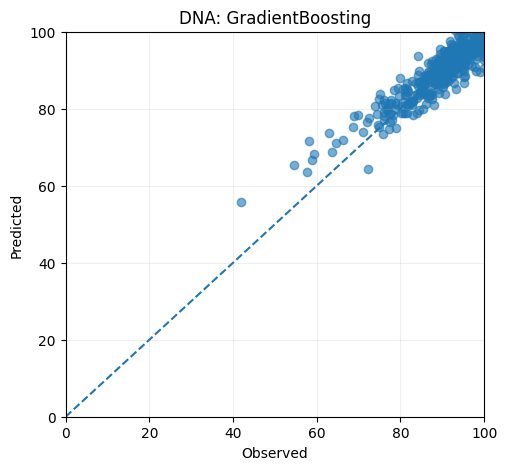

DNA GradientBoosting R2= 0.8207 RMSE= 3.7067


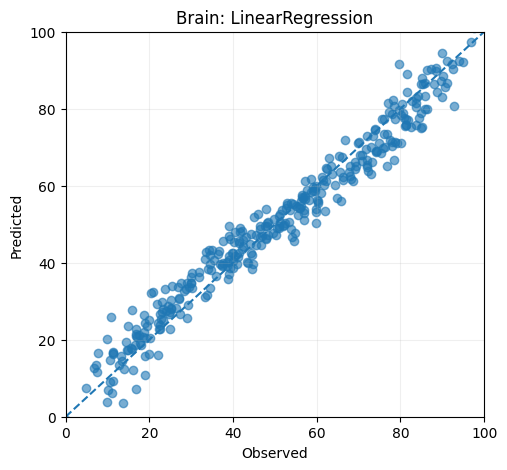

Brain LinearRegression R2= 0.9601 RMSE= 4.998


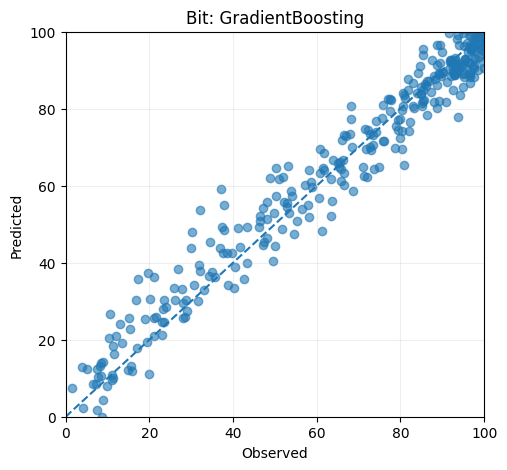

Bit GradientBoosting R2= 0.9603 RMSE= 6.0038


In [22]:

for label, fitted_bundle in [("DNA", dna_fitted), ("Brain", brain_fitted), ("Bit", bit_fitted)]:
    best_model_name = max(fitted_bundle, key=lambda k: r2_score(fitted_bundle[k][2], fitted_bundle[k][3]))
    model, X_test, y_test, pred = fitted_bundle[best_model_name]
    plt.figure(figsize=(5.4,5))
    plt.scatter(y_test, pred, alpha=0.6)
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(f"{label}: {best_model_name}")
    plt.plot([0,100],[0,100], linestyle="--")
    plt.xlim(0,100)
    plt.ylim(0,100)
    plt.grid(alpha=0.2)
    plt.show()
    print(label, best_model_name, "R2=", round(r2_score(y_test, pred), 4), "RMSE=", round(rmse(y_test, pred), 4))


## 6. Machine learning classification

In [25]:

def evaluate_classification_models(df, target_binary):
    X = df.drop(columns=[c for c in df.columns if c.startswith("high_")] + [c for c in df.columns if c.endswith("_score") or c.endswith("_fidelity")])
    y = df[target_binary]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    models = {
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "RandomForestClassifier": RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1),
        "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
        "MLPClassifier": MLPClassifier(hidden_layer_sizes=(32,16), max_iter=500, random_state=42)
    }
    results = []
    fitted = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1]) if hasattr(model, "predict_proba") else np.nan
        results.append({"model": name, "Accuracy": accuracy_score(y_test, pred), "ROC_AUC": auc})
        fitted[name] = (model, X_test, y_test, pred)
    return pd.DataFrame(results).sort_values("ROC_AUC", ascending=False), fitted

dna_cls_results, dna_cls_fitted = evaluate_classification_models(dna, "high_integrity_state")
brain_cls_results, brain_cls_fitted = evaluate_classification_models(brain, "high_memory_state")
bit_cls_results, bit_cls_fitted = evaluate_classification_models(bit, "high_reliability_state")

print("DNA")
display(dna_cls_results)
print("Brain")
display(brain_cls_results)
print("Bit")
display(bit_cls_results)


DNA


,model,Accuracy,ROC_AUC
0,LogisticRegression,0.965714,0.993994
2,GradientBoostingClassifier,0.968571,0.984102
1,RandomForestClassifier,0.962857,0.983748
3,MLPClassifier,0.951429,0.500000


Brain


,model,Accuracy,ROC_AUC
0,LogisticRegression,0.945714,0.987368
1,RandomForestClassifier,0.902857,0.976977
3,MLPClassifier,0.911429,0.972291
2,GradientBoostingClassifier,0.914286,0.972088


Bit


,model,Accuracy,ROC_AUC
0,LogisticRegression,0.960000,0.994921
2,GradientBoostingClassifier,0.934286,0.985006
1,RandomForestClassifier,0.902857,0.976852
3,MLPClassifier,0.860000,0.942717


In [27]:

for label, fitted_bundle in [("DNA", dna_cls_fitted), ("Brain", brain_cls_fitted), ("Bit", bit_cls_fitted)]:
    best_model_name = max(fitted_bundle, key=lambda k: accuracy_score(fitted_bundle[k][2], fitted_bundle[k][3]))
    model, X_test, y_test, pred = fitted_bundle[best_model_name]
    print("\n", label, best_model_name)
    print(classification_report(y_test, pred, digits=3))



 DNA GradientBoostingClassifier
              precision    recall  f1-score   support

           0      0.800     0.471     0.593        17
           1      0.974     0.994     0.984       333

    accuracy                          0.969       350
   macro avg      0.887     0.732     0.788       350
weighted avg      0.965     0.969     0.965       350


 Brain LogisticRegression
              precision    recall  f1-score   support

           0      0.953     0.972     0.963       253
           1      0.924     0.876     0.899        97

    accuracy                          0.946       350
   macro avg      0.939     0.924     0.931       350
weighted avg      0.945     0.946     0.945       350


 Bit LogisticRegression
              precision    recall  f1-score   support

           0      0.948     0.948     0.948       134
           1      0.968     0.968     0.968       216

    accuracy                          0.960       350
   macro avg      0.958     0.958     0.958

## 7. Permutation importance

DNA importance (GradientBoosting)


,feature,importance_mean,importance_std
3,chromatin_remodeling_index,0.427389,0.034627
0,lesions_per_day,0.399506,0.041014
4,replication_stress_index,0.271282,0.041769
1,oxidative_fraction,0.270935,0.024249
5,antioxidant_capacity_index,0.224491,0.026099
6,cell_cycle_pressure_index,0.099167,0.011310
2,repair_efficiency,0.002999,0.001825


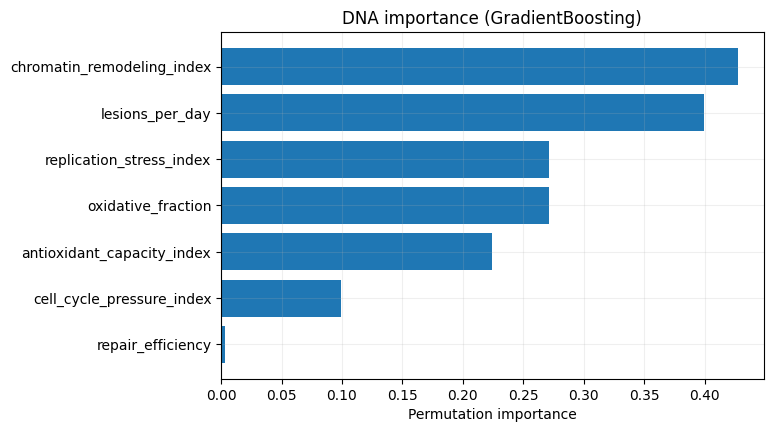

Brain importance (LinearRegression)


,feature,importance_mean,importance_std
3,protein_synthesis_index,0.625721,0.031794
4,synaptic_remodeling_index,0.509387,0.022521
7,injury_burden_index,0.307957,0.017652
6,oxidative_stress_index,0.151856,0.006067
0,cmr_glucose_umol_g_min,0.119968,0.004798
2,glycogen_umol_g,0.100402,0.005876
1,activity_increase_pct,0.081088,0.007004
5,sleep_support_index,0.061168,0.003140


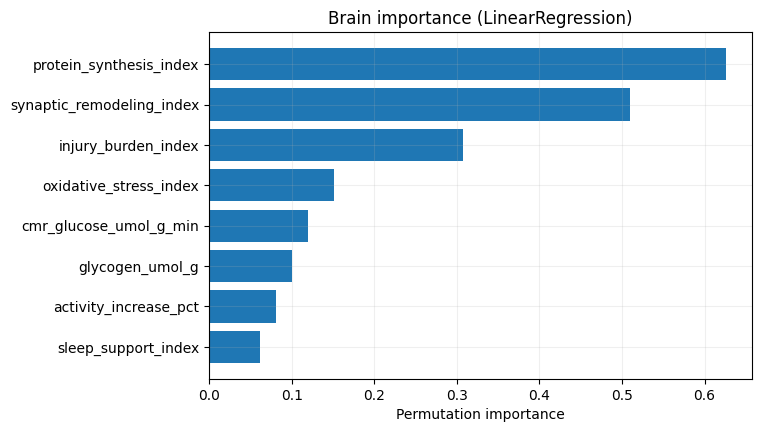

Bit importance (GradientBoosting)


,feature,importance_mean,importance_std
1,energy_barrier_multiple_of_landauer,1.469118,0.070933
2,leakage_index,0.128232,0.008190
3,error_correction_strength,0.069391,0.005509
5,radiation_noise_index,0.052845,0.003463
0,temperature_K,0.048678,0.003746
6,landauer_bound_J,0.045397,0.003156
4,switching_frequency_GHz,0.010079,0.001012
7,practical_reset_energy_J,0.004187,0.000727


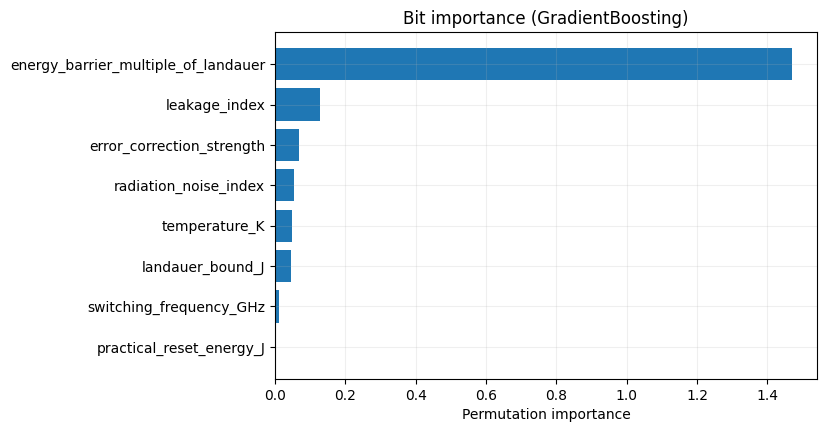

In [30]:

def permutation_importance_table(model, X_test, y_test, title):
    imp = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    out = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": imp.importances_mean,
        "importance_std": imp.importances_std
    }).sort_values("importance_mean", ascending=False)
    print(title)
    display(out.head(10))
    plt.figure(figsize=(7,4.5))
    plt.barh(out["feature"].head(10)[::-1], out["importance_mean"].head(10)[::-1])
    plt.xlabel("Permutation importance")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.show()

for label, fitted_bundle in [("DNA", dna_fitted), ("Brain", brain_fitted), ("Bit", bit_fitted)]:
    best_model_name = max(fitted_bundle, key=lambda k: r2_score(fitted_bundle[k][2], fitted_bundle[k][3]))
    model, X_test, y_test, pred = fitted_bundle[best_model_name]
    permutation_importance_table(model, X_test, y_test, f"{label} importance ({best_model_name})")


## 8. Cross-system integration

In [33]:

dna_common = dna.rename(columns={"dna_information_fidelity":"information_score"}).assign(system="DNA")
brain_common = brain.rename(columns={"memory_retention_score":"information_score"}).assign(system="Brain")
bit_common = bit.rename(columns={"bit_reliability_score":"information_score"}).assign(system="Bit")

common = pd.concat([
    dna_common[["system","information_score","repair_efficiency","chromatin_remodeling_index","replication_stress_index","antioxidant_capacity_index"]]
      .rename(columns={"repair_efficiency":"stability_index","chromatin_remodeling_index":"energy_support_index",
                       "replication_stress_index":"noise_index","antioxidant_capacity_index":"adaptation_index"}),
    brain_common[["system","information_score","protein_synthesis_index","cmr_glucose_umol_g_min","oxidative_stress_index","synaptic_remodeling_index"]]
      .rename(columns={"protein_synthesis_index":"stability_index","cmr_glucose_umol_g_min":"energy_support_index",
                       "oxidative_stress_index":"noise_index","synaptic_remodeling_index":"adaptation_index"}),
    bit_common[["system","information_score","energy_barrier_multiple_of_landauer","practical_reset_energy_J","leakage_index","error_correction_strength"]]
      .rename(columns={"energy_barrier_multiple_of_landauer":"stability_index","practical_reset_energy_J":"energy_support_index",
                       "leakage_index":"noise_index","error_correction_strength":"adaptation_index"})
], ignore_index=True)

common.head()


,system,information_score,stability_index,energy_support_index,noise_index,adaptation_index
0,DNA,93.351635,0.987159,1.774939,0.268143,0.250439
1,DNA,82.906582,0.994020,0.794369,0.315668,0.442804
2,DNA,95.979022,0.996150,0.688325,0.125251,1.280620
3,DNA,91.916332,0.997128,1.945220,0.655510,1.196799
4,DNA,96.289084,0.971027,0.662067,0.039797,0.655835


Cross-system R2 : 0.8249
Cross-system MAE: 8.1914
Cross-system RMSE: 11.2716


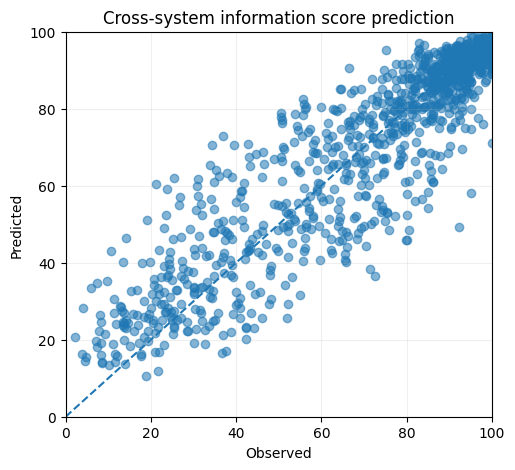

In [35]:

X = common[["system","stability_index","energy_support_index","noise_index","adaptation_index"]].copy()
X["energy_support_index"] = np.log10(X["energy_support_index"].replace(0, np.nan)).fillna(0)
y = common["information_score"]

numeric_features = ["stability_index","energy_support_index","noise_index","adaptation_index"]
categorical_features = ["system"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

cross_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
cross_model.fit(X_train, y_train)
pred = cross_model.predict(X_test)

print("Cross-system R2 :", round(r2_score(y_test, pred), 4))
print("Cross-system MAE:", round(mean_absolute_error(y_test, pred), 4))
print("Cross-system RMSE:", round(rmse(y_test, pred), 4))

plt.figure(figsize=(5.5,5))
plt.scatter(y_test, pred, alpha=0.55)
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Cross-system information score prediction")
plt.plot([0,100],[0,100], linestyle="--")
plt.xlim(0,100)
plt.ylim(0,100)
plt.grid(alpha=0.2)
plt.show()


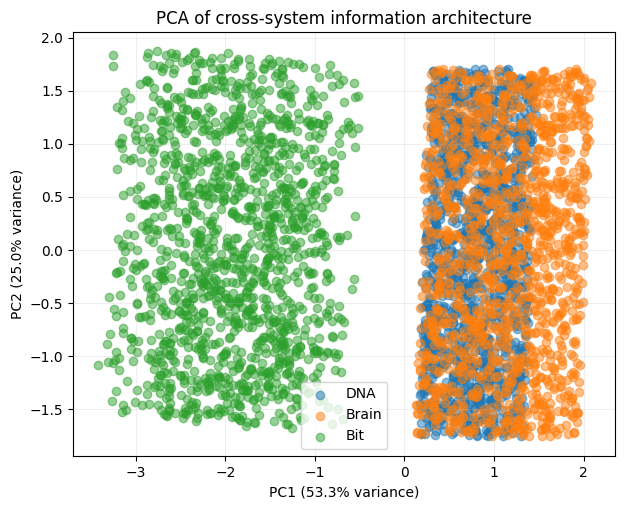

cluster,0,1,2
system,,,
Bit,3,1396,1
Brain,748,0,652
DNA,676,0,724


In [37]:

X_embed = common[["stability_index","noise_index","adaptation_index"]].copy()
X_embed["energy_support_log"] = np.log10(common["energy_support_index"].replace(0, np.nan)).fillna(0)

scaled = StandardScaler().fit_transform(X_embed)
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(scaled)
km = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = km.fit_predict(scaled)

pca_df = pd.DataFrame({
    "PC1": pcs[:,0],
    "PC2": pcs[:,1],
    "system": common["system"].values,
    "cluster": clusters,
    "information_score": common["information_score"].values
})

plt.figure(figsize=(7,5.5))
for sys_name in pca_df["system"].unique():
    sub = pca_df[pca_df["system"] == sys_name]
    plt.scatter(sub["PC1"], sub["PC2"], alpha=0.5, label=sys_name)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of cross-system information architecture")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

pca_df.groupby(["system","cluster"]).size().unstack(fill_value=0)


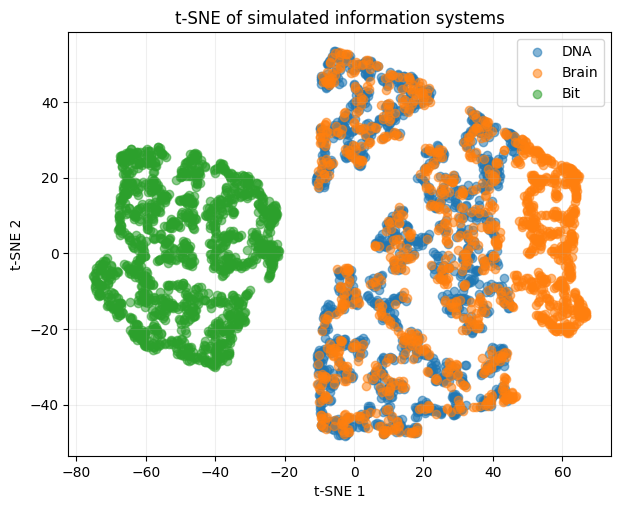

In [39]:

tsne = TSNE(n_components=2, random_state=42, perplexity=35, init="pca", learning_rate="auto")
tsne_coords = tsne.fit_transform(scaled)

tsne_df = pd.DataFrame({
    "TSNE1": tsne_coords[:,0],
    "TSNE2": tsne_coords[:,1],
    "system": common["system"].values
})

plt.figure(figsize=(7,5.5))
for sys_name in tsne_df["system"].unique():
    sub = tsne_df[tsne_df["system"] == sys_name]
    plt.scatter(sub["TSNE1"], sub["TSNE2"], alpha=0.55, label=sys_name)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of simulated information systems")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 9. Comparative thermodynamic plots

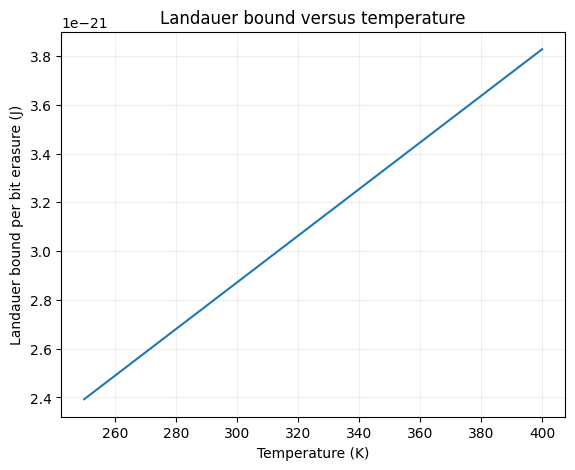

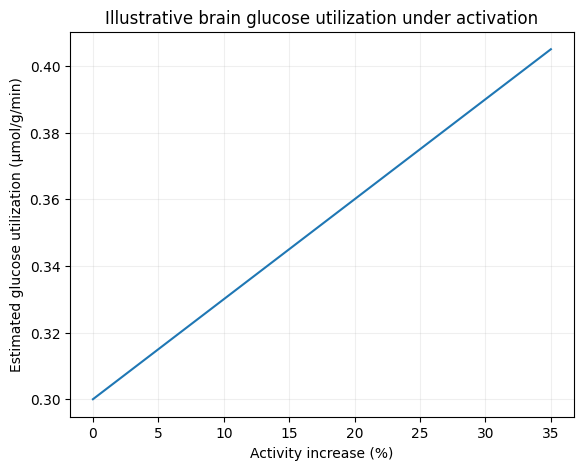

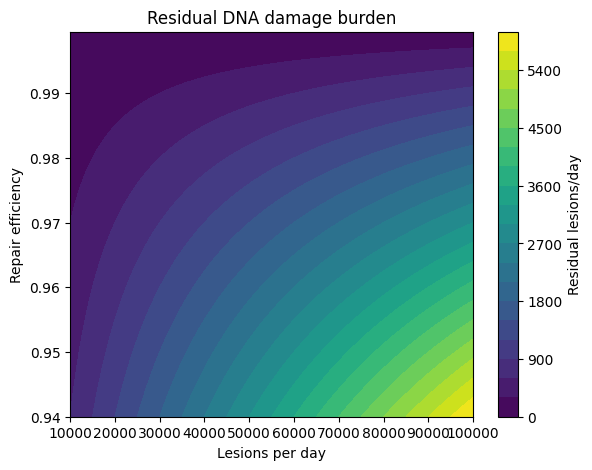

In [41]:

temps = np.linspace(250, 400, 200)
landauer = k_B * temps * np.log(2)
plt.figure(figsize=(6.5,5))
plt.plot(temps, landauer)
plt.xlabel("Temperature (K)")
plt.ylabel("Landauer bound per bit erasure (J)")
plt.title("Landauer bound versus temperature")
plt.grid(alpha=0.2)
plt.show()

activation = np.linspace(0, 35, 200)
cmr = 0.30 * (1 + activation / 100)
plt.figure(figsize=(6.5,5))
plt.plot(activation, cmr)
plt.xlabel("Activity increase (%)")
plt.ylabel("Estimated glucose utilization (μmol/g/min)")
plt.title("Illustrative brain glucose utilization under activation")
plt.grid(alpha=0.2)
plt.show()

lesion_axis = np.linspace(1e4, 1e5, 150)
repair_axis = np.linspace(0.94, 0.9995, 150)
L, R = np.meshgrid(lesion_axis, repair_axis)
resid = L * (1 - R)
plt.figure(figsize=(6.5,5))
plt.contourf(L, R, resid, levels=20)
plt.xlabel("Lesions per day")
plt.ylabel("Repair efficiency")
plt.title("Residual DNA damage burden")
plt.colorbar(label="Residual lesions/day")
plt.show()



## 10. Interpretation

This notebook treats three very different systems, DNA, brain memory, and computer bits, as **distinct physical implementations of information storage**. The machine-learning sections do not claim discovery from artificial data. Instead, they test whether a shared comparative structure can be recovered computationally:
- stored information
- physical embodiment
- susceptibility to entropy
- need for energy

The expected patterns are intentionally built into the simulator:
- higher DNA repair and chromatin support improve genomic information fidelity,
- higher brain metabolic and translational support improve memory-related stability,
- stronger barriers and error correction improve bit reliability,
- higher stress, leakage, oxidative burden, and thermal pressure reduce information-preserving performance.

That structure makes the notebook useful as a **teaching, methods-development, and hypothesis-generation scaffold** for future work using real datasets.

### End of notebook